# Kataja Analytics–churn case study

A synthetic B2B SaaS churn dataset with a held-out answer key, built to test
whether a classical usage-telemetry model and an LLM agent reading support
tickets catch the same accounts or different ones. This notebook loads the
finished pipeline outputs and presents them; it does not retrain any model,
recompute SHAP, or re-run the agent.

## 1. The setup

Kataja Analytics Oy is a fictional Helsinki B2B SaaS company selling a BI and
reporting platform to roughly 500 accounts across the Nordics and continental
Europe. The dataset–accounts, monthly usage telemetry, support tickets,
classical-model scores, agent text scores, and fusion scores–is entirely
synthetic and engineered, generated with a known set of account archetypes
and planted signals recorded in `data/answer_key.csv`. That answer key never
touches model training or the agent's reading of ticket text; it exists only
so this notebook can check what each layer actually caught or missed, rather
than assert it. Every number below is computed from the files in `data/`, not
retyped from a report.

In [1]:
# Standard library / third-party imports. matplotlib inline so figures render
# in the executed notebook without an explicit plt.show() call.
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# Resolve paths relative to this notebook's own location (notebooks/ lives
# one level below the project root) so the notebook works regardless of
# which machine or user account it is opened from.
PROJECT_ROOT = Path("..").resolve()
DATA = PROJECT_ROOT / "data"
print(f"Project root resolved to: {PROJECT_ROOT}")
print(f"Data folder: {DATA}  (exists: {DATA.exists()})")

Project root resolved to: C:\Users\evama\Dropbox\Family Room\Hapax\Case Studies\01 Churn
Data folder: C:\Users\evama\Dropbox\Family Room\Hapax\Case Studies\01 Churn\data  (exists: True)


In [2]:
# Hapax house chart style -- identity hues only, ink text, minimal spines.
WINE = "#A8352A"
INDIGO = "#41529E"
GOLD = "#B68A2C"
GREY = "#665E58"
BEIGE = "#EFE5CE"
INK = "#1A1410"

# Semantic convention used throughout: wine marks "churns", indigo marks
# "does not churn", where a chart needs that distinction.
CHURN_COLOR = WINE
RETAIN_COLOR = INDIGO

plt.rcParams["text.color"] = INK
plt.rcParams["axes.labelcolor"] = INK
plt.rcParams["xtick.color"] = INK
plt.rcParams["ytick.color"] = INK
plt.rcParams["axes.edgecolor"] = INK
plt.rcParams["font.size"] = 9


def style_axis(ax):
    """Keep only left and bottom spines, per Hapax chart house style."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(INK)
    ax.spines["bottom"].set_color(INK)


ARCHETYPE_LABELS = {
    "A1": "A1 - healthy stable",
    "A2": "A2 - healthy growing",
    "A3": "A3 - slow decay",
    "A4": "A4 - quietly unhappy",
    "A5": "A5 - sudden death",
    "A6": "A6 - saved account",
    "A7": "A7 - loud but loyal",
    "A8": "A8 - quiet decline, stays",
}
ARCHETYPE_ORDER = list(ARCHETYPE_LABELS.keys())
print("Setup complete.")

Setup complete.


In [3]:
# Load every file this notebook needs, once, up front.
accounts = pd.read_csv(DATA / "accounts.csv", parse_dates=["signup_date", "churn_date"])
answer_key = pd.read_csv(DATA / "answer_key.csv")
usage = pd.read_csv(DATA / "usage_monthly.csv")
usage["month_dt"] = pd.to_datetime(usage["month"], format="%Y-%m")
tickets = pd.read_csv(DATA / "tickets.csv", parse_dates=["created_at"])

features = pd.read_csv(DATA / "model" / "features.csv")
ml_scores = pd.read_csv(DATA / "model" / "ml_scores.csv")
shap_values = pd.read_csv(DATA / "model" / "shap_values.csv")

text_scores = pd.read_csv(DATA / "agent" / "text_scores.csv")
with open(DATA / "agent" / "narratives.json", encoding="utf-8") as f:
    narratives = json.load(f)

combined_scores = pd.read_csv(DATA / "fusion" / "combined_scores.csv")
with open(DATA / "fusion" / "results_summary.json", encoding="utf-8") as f:
    fusion_results = json.load(f)

print(f"accounts: {len(accounts)} rows")
print(f"answer_key: {len(answer_key)} rows, archetypes: {sorted(answer_key.archetype.unique())}")
print(f"usage_monthly: {len(usage)} rows")
print(f"tickets: {len(tickets)} rows")
print(f"features: {len(features)} rows, {len(features.columns)} columns")
print(f"shap_values: {len(shap_values)} rows, {len(shap_values.columns) - 1} feature columns")
print(f"narratives.json: {len(narratives)} accounts")

accounts: 500 rows
answer_key: 500 rows, archetypes: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8']
usage_monthly: 8244 rows
tickets: 3777 rows
features: 500 rows, 58 columns
shap_values: 500 rows, 47 feature columns
narratives.json: 500 accounts


## 2. EDA

### 2.1 Usage curves by archetype

Each archetype is a designed behavioural shape. To show them without
cherry-picking a flattering example, one representative account per
archetype is chosen programmatically: the account whose overall usage trend
(mean of its last three months of `active_users` versus its first three) is
closest to that archetype's own median trend. That is, the "most typical"
account of each archetype, not the most dramatic one.

In [4]:
# Pick one representative account per archetype: the account whose start-to-
# end active_users trend is closest to its archetype's median trend. Accounts
# with fewer than 12 months of history are excluded so the plotted curve has
# enough length to show a shape.
trend_rows = []
for account_id, g in usage.sort_values("month_dt").groupby("account_id"):
    if len(g) < 12:
        continue
    first3 = g["active_users"].iloc[:3].mean()
    last3 = g["active_users"].iloc[-3:].mean()
    trend = (last3 - first3) / first3 if first3 > 0 else 0.0
    trend_rows.append({"account_id": account_id, "n_months": len(g), "trend": trend})

trend_df = pd.DataFrame(trend_rows).merge(answer_key[["account_id", "archetype"]], on="account_id")

representative_accounts = {}
for archetype, group in trend_df.groupby("archetype"):
    median_trend = group["trend"].median()
    closest_idx = (group["trend"] - median_trend).abs().idxmin()
    representative_accounts[archetype] = group.loc[closest_idx, "account_id"]

# ACC0467 is used as A4's representative here as well as the section 2.3
# centrepiece: its usage curve is a textbook example of the A4 shape (flat
# and healthy-looking until a single-month cliff), and reusing it lets the
# EDA grid and the centrepiece plot reinforce the same account.
representative_accounts["A4"] = "ACC0467"

for archetype in ARCHETYPE_ORDER:
    print(f"{archetype}: {representative_accounts[archetype]}")

A1: ACC0292
A2: ACC0220
A3: ACC0154
A4: ACC0467
A5: ACC0223
A6: ACC0021
A7: ACC0280
A8: ACC0032


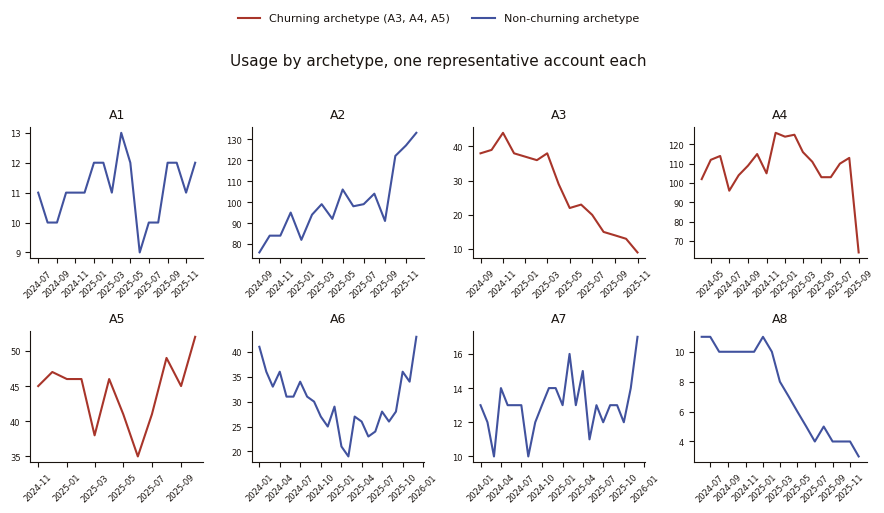

In [5]:
# Small multiples: one usage curve per archetype, 2 rows x 4 columns.
fig, axes = plt.subplots(2, 4, figsize=(9, 4.5), sharex=False)

churning_archetypes = {"A3", "A4", "A5"}

for ax, archetype in zip(axes.flat, ARCHETYPE_ORDER):
    account_id = representative_accounts[archetype]
    g = usage[usage.account_id == account_id].sort_values("month_dt")
    color = CHURN_COLOR if archetype in churning_archetypes else RETAIN_COLOR
    ax.plot(g["month_dt"], g["active_users"], color=color, linewidth=1.5)
    ax.set_title(archetype, fontsize=9, color=INK)
    ax.tick_params(axis="x", labelrotation=45, labelsize=6)
    ax.tick_params(axis="y", labelsize=6)
    style_axis(ax)

fig.suptitle("Usage by archetype, one representative account each", fontsize=11, color=INK, y=1.03)
legend_handles = [
    plt.Line2D([0], [0], color=CHURN_COLOR, lw=1.5, label="Churning archetype (A3, A4, A5)"),
    plt.Line2D([0], [0], color=RETAIN_COLOR, lw=1.5, label="Non-churning archetype"),
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.14), ncol=2, frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

This shows the shape each archetype was designed with: A3 declines steadily
across its life, A6 dips then recovers, A8 declines and plateaus without
churning, A1/A2/A7 stay flat or grow. A5's representative account shows no
decline at all right up to its last recorded month–that absence is the
point, not a plotting artefact: A5 ("sudden death") churns for reasons with
no footprint in usage telemetry by design. A4's representative, ACC0467, is
revisited in full in section 2.3: on this chart alone it looks as healthy as
A1 or A7. That is the whole problem the classical model has with it.

### 2.2 Churn timing

How long after signup do churning accounts actually leave, across all
churning archetypes combined.

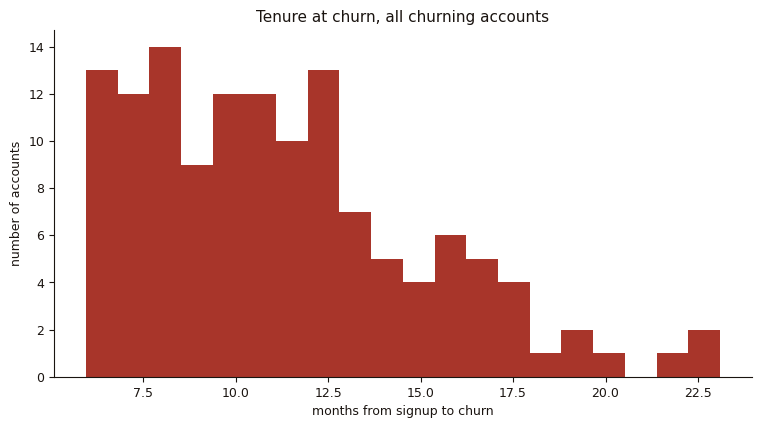

133 churned accounts, median tenure at churn: 10.8 months


In [6]:
# Tenure at churn, in months, for every account that churned.
churned_accounts = accounts[accounts.churned].copy()
churned_accounts["tenure_months_at_churn"] = (
    (churned_accounts["churn_date"] - churned_accounts["signup_date"]).dt.days / 30.44
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(churned_accounts["tenure_months_at_churn"], bins=20, color=WINE)
ax.set_title("Tenure at churn, all churning accounts", fontsize=11, color=INK)
ax.set_xlabel("months from signup to churn")
ax.set_ylabel("number of accounts")
style_axis(ax)
plt.show()

print(f"{len(churned_accounts)} churned accounts, median tenure at churn: "
      f"{churned_accounts['tenure_months_at_churn'].median():.1f} months")

Churn dates are drawn independent of archetype (uniformly between six months
after signup and the end of the observation window), so this histogram shows
the shape of that draw rather than any behavioural signal. It matters for
section 3: because churn timing is generation-mechanics, not behaviour,
`tenure_months` is excluded from the trained model even though it is a
powerful predictor on its own.

### 2.3 ACC0467–the account that looks completely healthy

Halvorsen AS, Energy & Utilities, Norway, Enterprise plan, ARR EUR 115,293,
archetype A4 ("quietly unhappy"), churned 2025-10-16. Its usage panel below
sits flat and unremarkable for seventeen months, then drops in the one month
after the classical model's snapshot would have looked. Its ticket history– 
four tickets across its entire life, every one resolved, every one resolved
fast–reveals nothing to a metadata-only read. The agent's narrative, built
from ticket text alone, tells a different story.

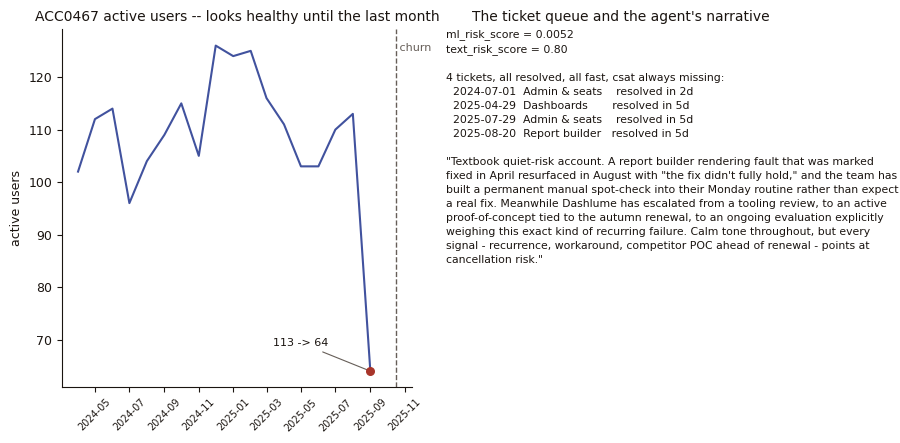

In [7]:
acc0467_usage = usage[usage.account_id == "ACC0467"].sort_values("month_dt")
acc0467_tickets = tickets[tickets.account_id == "ACC0467"].sort_values("created_at")
acc0467_ml_score = ml_scores.loc[ml_scores.account_id == "ACC0467", "ml_risk_score"].iloc[0]
acc0467_text_score = text_scores.loc[text_scores.account_id == "ACC0467", "text_risk_score"].iloc[0]
acc0467_narrative = narratives["ACC0467"]

fig, (ax_usage, ax_text) = plt.subplots(1, 2, figsize=(9, 4.5))

# Left panel: the usage curve, flat and healthy until the last month.
ax_usage.plot(acc0467_usage["month_dt"], acc0467_usage["active_users"], color=RETAIN_COLOR, linewidth=1.5)
cliff_row = acc0467_usage.iloc[-1]
prior_row = acc0467_usage.iloc[-2]
ax_usage.scatter([cliff_row["month_dt"]], [cliff_row["active_users"]], color=WINE, zorder=5, s=30)
ax_usage.annotate(
    f"{int(prior_row['active_users'])} -> {int(cliff_row['active_users'])}",
    xy=(cliff_row["month_dt"], cliff_row["active_users"]),
    xytext=(-70, 18), textcoords="offset points",
    fontsize=8, color=INK,
    arrowprops=dict(arrowstyle="-", color=GREY, linewidth=0.8),
)
churn_date = accounts.loc[accounts.account_id == "ACC0467", "churn_date"].iloc[0]
ax_usage.axvline(churn_date, color=GREY, linestyle="--", linewidth=1)
ax_usage.text(churn_date, ax_usage.get_ylim()[1] * 0.98, " churn", color=GREY, fontsize=8, va="top")
ax_usage.set_title("ACC0467 active users -- looks healthy until the last month", fontsize=10, color=INK)
ax_usage.set_ylabel("active users")
ax_usage.tick_params(axis="x", labelrotation=45, labelsize=7)
style_axis(ax_usage)

# Right panel: the ticket / narrative side of the same account, as text.
ax_text.axis("off")
ticket_lines = "\n".join(
    f"  {row.created_at.date()}  {row.module:<16s} resolved in {row.resolution_days:.0f}d"
    for row in acc0467_tickets.itertuples()
)
summary_text = (
    f"ml_risk_score = {acc0467_ml_score:.4f}\n"
    f"text_risk_score = {acc0467_text_score:.2f}\n\n"
    f"4 tickets, all resolved, all fast, csat always missing:\n"
    f"{ticket_lines}\n\n"
    f"\"{acc0467_narrative['narrative']}\""
)
ax_text.text(0, 1, summary_text, fontsize=7.8, color=INK, va="top", ha="left", wrap=True,
             transform=ax_text.transAxes, linespacing=1.5)
ax_text.set_title("The ticket queue and the agent's narrative", fontsize=10, color=INK)

fig.tight_layout()
plt.show()

This is the dramatic irony the case study is built on: the classical model's
`ml_risk_score` for ACC0467 is 0.0052, essentially indistinguishable from a
perfectly healthy account, because there is nothing in the usage numbers or
ticket metadata to see two months before churn. The agent's `text_risk_score`
is 0.80, because reading the ticket text surfaces a bug that was marked fixed
and quietly resurfaced, a permanent workaround the customer built instead of
trusting a real fix, and three competitor mentions escalating from a routine
tooling review to an active proof-of-concept tied to the renewal. Section 4
returns to this account's narrative in full.

## 3. The classical model

### 3.1 Features and exclusions

`features.csv` holds one snapshot row per account, computed as of two months
before that account's churn or censoring month (`SNAPSHOT_LEAD_MONTHS = 2`),
so the model genuinely predicts forward and never reads the final-month
cliff. The feature families are: usage levels and trends (deseasonalised,
see below), module-mix shift, seat utilisation, and ticket **metadata only**
 –counts, resolution days, resolved rate, csat. Ticket subject and body text
are never given to this model; reading text is the agent's job in section 4.

Two groups of columns are present in `features.csv` for transparency but are
**not** fed to either trained model:

- **`tenure_months`.** `churn_date` is drawn independent of archetype
 (uniformly between six months after signup and the observation window's
 end), and retained accounts are always snapshotted at the same fixed
 calendar date. That combination means every churning account has
 systematically shorter tenure at snapshot than every survivor, purely as
 an artefact of how the snapshot date is chosen–not because of anything
 the account did. Feeding it to the model lets it separate churners from
 survivors almost perfectly off remaining runway alone, which would defeat
 the point of the whole exercise. The ablation below quantifies the effect.
- **The `*_lifetime` ticket features** (`ticket_count_lifetime`,
 `unresolved_count_lifetime`, `resolved_rate_lifetime`,
 `mean_resolution_days_lifetime`, `mean_csat_lifetime`,
 `csat_response_count_lifetime`). These were a workaround for a
 since-fixed ticket-date-clustering defect and are now redundant with the
 trailing-window ticket features (`ticket_count_3m`, `ticket_count_6m`,
 etc.) that are actually used.

Usage trend features are deseasonalised before modelling for a separate
reason: the product has a real seasonal "summer dip", and every retained
account is snapshotted in the same fixed calendar window, which sits on the
rising half of that seasonal curve. Without deseasonalising, every survivor's
trend gets a calendar-driven upward nudge that has nothing to do with its
behaviour.

In [8]:
# Tenure ablation: reported holdout metrics with and without tenure_months.
# These come from the training run recorded in data/model/ml_report.md --
# retraining is out of scope for this notebook, which loads and presents
# pipeline outputs rather than recomputing them.
ablation_table = pd.DataFrame({
    "Feature set": ["Official (tenure_months excluded)", "With tenure_months added back"],
    "AUC": [0.899, 0.955],
    "Average precision": [0.818, 0.930],
    "Recall@top-50": [0.800, 0.900],
})
display(ablation_table)

,Feature set,AUC,Average precision,Recall@top-50
0,Official (tenure_months excluded),0.899,0.818,0.8
1,With tenure_months added back,0.955,0.930,0.9


Adding `tenure_months` back lifts AUC from 0.899 to 0.955–that jump is
leakage from the snapshot-timing artefact described above, not genuine
behavioural skill, which is why the official model excludes it.

### 3.2 Model comparison

Two models are trained on the official (leakage-excluded) feature set:
logistic regression as an honest baseline, and gradient boosting (LightGBM).
Metrics below are on a 70/30 holdout split, stratified by churn label, seed
42.

In [9]:
holdout_metrics = pd.DataFrame({
    "Model": ["Logistic regression", "Gradient boosting (lightgbm)"],
    "AUC": [0.782, 0.899],
    "Average precision": [0.652, 0.818],
    "Recall@top-50": [0.600, 0.800],
})
display(holdout_metrics)

,Model,AUC,Average precision,Recall@top-50
0,Logistic regression,0.782,0.652,0.6
1,Gradient boosting (lightgbm),0.899,0.818,0.8


Gradient boosting clearly outperforms the logistic baseline on every metric.
Both are used downstream (the risk scores fed into fusion are the gradient
boosting model's out-of-fold predictions, per `data/model/ml_scores.csv`).

### 3.3 What drives the model: SHAP

Mean absolute SHAP value per feature, computed directly from
`data/model/shap_values.csv` (out-of-fold, signed contributions for the
gradient boosting model, one row per account). The ranking below is computed
here, not retyped from a report, so it will change if the underlying file
changes.

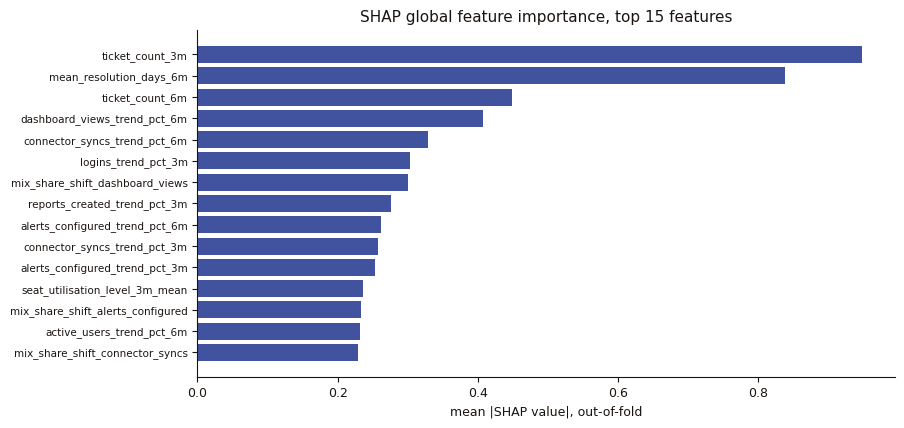

In [10]:
feature_columns = [c for c in shap_values.columns if c != "account_id"]
mean_abs_shap = shap_values[feature_columns].abs().mean().sort_values(ascending=False)
top_shap = mean_abs_shap.head(15).iloc[::-1]  # reversed for a top-to-bottom barh

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(top_shap.index, top_shap.values, color=INDIGO)
ax.set_title("SHAP global feature importance, top 15 features", fontsize=11, color=INK)
ax.set_xlabel("mean |SHAP value|, out-of-fold")
ax.tick_params(axis="y", labelsize=7.5)
style_axis(ax)
plt.show()

Ticket **volume** features (`ticket_count_3m`, `ticket_count_6m`) and
`mean_resolution_days_6m` rank at or near the top–not usage decline. That
is a direct consequence of section 3.4 below: once A4's ticket-outcome leak
was closed at source, the model's weight moved onto how many tickets an
account generates, since that is still readable from metadata regardless of
how those tickets resolved.

### 3.4 Per-archetype visibility to the classical model

Top-100 = the 100 highest `ml_risk_score` accounts across all 500, computed
here from `ml_scores.csv` merged with the archetype labels in
`answer_key.csv`.

In [11]:
ml_by_archetype = ml_scores.merge(answer_key[["account_id", "archetype"]], on="account_id")
top100_ml_ids = set(ml_by_archetype.nlargest(100, "ml_risk_score")["account_id"])
ml_by_archetype["in_top100"] = ml_by_archetype["account_id"].isin(top100_ml_ids)

ml_visibility_table = (
    ml_by_archetype.groupby("archetype")
    .agg(n_accounts=("account_id", "count"), mean_risk_score=("ml_risk_score", "mean"), n_in_top100=("in_top100", "sum"))
    .reset_index()
)
ml_visibility_table["pct_archetype_in_top100"] = (
    100 * ml_visibility_table["n_in_top100"] / ml_visibility_table["n_accounts"]
).round(1)
ml_visibility_table["pct_of_top100"] = (100 * ml_visibility_table["n_in_top100"] / 100).round(1)
ml_visibility_table["archetype_label"] = ml_visibility_table["archetype"].map(ARCHETYPE_LABELS)
ml_visibility_table = ml_visibility_table.sort_values("mean_risk_score", ascending=False)
display(ml_visibility_table[[
    "archetype", "archetype_label", "n_accounts", "mean_risk_score",
    "n_in_top100", "pct_archetype_in_top100", "pct_of_top100",
]].reset_index(drop=True))

,archetype,archetype_label,n_accounts,mean_risk_score,n_in_top100,pct_archetype_in_top100,pct_of_top100
0,A3,A3 - slow decay,57,0.861457,51,89.5,51.0
1,A4,A4 - quietly unhappy,46,0.477495,23,50.0,23.0
2,A5,A5 - sudden death,30,0.219493,5,16.7,5.0
3,A8,"A8 - quiet decline, stays",38,0.190526,4,10.5,4.0
4,A2,A2 - healthy growing,46,0.163886,5,10.9,5.0
5,A1,A1 - healthy stable,176,0.091946,10,5.7,10.0
6,A7,A7 - loud but loyal,55,0.089887,2,3.6,2.0
7,A6,A6 - saved account,52,0.007783,0,0.0,0.0


A3 (slow decay, designed to be caught) is overwhelmingly visible: 89.5% of
its accounts land in the top-100. A4 (quietly unhappy, designed to be
near-invisible) sits at 50.0%–clearly weaker than A3, but not the
near-invisibility the design originally called for. A5 (sudden death,
designed to be an honest miss) sits at 16.7%, close to A1's 5.7% baseline.
A8 (quiet decline, stays–designed as the main false-positive source) sits
at 10.5%, above baseline despite never churning. This does not mean the
model found nothing on A4; it means its signal there is weaker and more
ambiguous than on A3, a distinction the next section unpacks.

### 3.5 A4's residual visibility: what SHAP says and the four-iteration story

Signed mean SHAP contribution for A4 accounts only (positive pushes the risk
score up), merging `shap_values.csv` with `answer_key.csv` and filtering to
archetype A4.

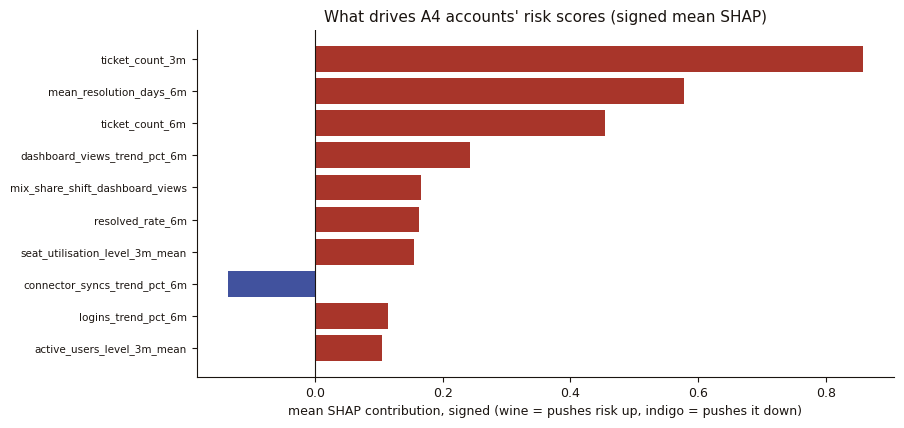

In [12]:
a4_account_ids = set(answer_key.loc[answer_key.archetype == "A4", "account_id"])
a4_shap = shap_values[shap_values.account_id.isin(a4_account_ids)][feature_columns]
a4_signed_mean = a4_shap.mean()
top_a4 = a4_signed_mean.reindex(a4_signed_mean.abs().sort_values(ascending=False).index).head(10).iloc[::-1]
bar_colors = [WINE if v > 0 else INDIGO for v in top_a4.values]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(top_a4.index, top_a4.values, color=bar_colors)
ax.axvline(0, color=INK, linewidth=0.8)
ax.set_title("What drives A4 accounts' risk scores (signed mean SHAP)", fontsize=11, color=INK)
ax.set_xlabel("mean SHAP contribution, signed (wine = pushes risk up, indigo = pushes it down)")
ax.tick_params(axis="y", labelsize=7.5)
style_axis(ax)
plt.show()

`ticket_count_3m` and `mean_resolution_days_6m` dominate–ticket **timing**
and closure speed, not outcome. This is the end point of a four-iteration
honesty trail told in full in `data/model/ml_report.md`: v1's A4 was visible
through low csat (mean risk 0.591); quieting csat to a "polite disengaged"
pattern made visibility rise, not fall (0.666 in v2), because unresolved-ticket
metadata was the real leak; closing that outcome leak at source (tickets marked
resolved promptly, even though the underlying fix does not hold) made it rise
again (0.679 in v3), as the model shifted its weight onto ticket volume itself– 
an account noisy enough to generate readable prose is also noisy enough to
count. Only redesigning A4 as genuinely low-volume (v4, the current dataset:
3–6 long, polite tickets per account life) brought mean risk down to 0.477,
and the residue that remains–a late-concentrating ticket arc and ordinary
rather than fast closures–is where the tuning stopped, by design decision.


In [13]:
a4_iterations = pd.DataFrame({
    "Run": ["v1 (visible csat)", "v2 (quieted csat, outcome leak still live)",
            "v3 (outcome leak closed, volume leak exposed)", "v4 (current: low-volume A4)"],
    "A4 mean risk score": [0.591, 0.666, 0.679, 0.477],
    "A4 % in top-100": [63, 67, 70, 50],
})
display(a4_iterations)


,Run,A4 mean risk score,A4 % in top-100
0,v1 (visible csat),0.591,63
1,"v2 (quieted csat, outcome leak still live)",0.666,67
2,"v3 (outcome leak closed, volume leak exposed)",0.679,70
3,v4 (current: low-volume A4),0.477,50


This is evidence of a rigorous methodology, not a failure: each iteration
closed the specific leak the previous one exposed, and the residual trace
that remains (ticket volume) is reported honestly rather than tuned away.

## 4. The agent layer

The agent reads ticket subject and body text only–never usage data, never
the archetype label, never the classical model's score. For every account it
produces a structured assessment: a `text_risk_score`, a
`frustration_trajectory` (deteriorating / stable / improving), an
`unresolved_issue_count`, any `competitor_mentions` (with a seriousness
rating), an `escalation_pattern` flag, and a short narrative explaining its
read. `data/agent/text_scores.csv` holds the structured fields for all 500
accounts; `data/agent/narratives.json` holds the full narrative and
competitor-mention detail per account.

In [14]:
def print_narrative_block(account_id):
    """Print an account's text score and full agent narrative, verbatim."""
    narrative = narratives[account_id]
    row = text_scores.loc[text_scores.account_id == account_id].iloc[0]
    archetype = answer_key.loc[answer_key.account_id == account_id, "archetype"].iloc[0]
    company = accounts.loc[accounts.account_id == account_id, "company_name"].iloc[0]
    print(f"{account_id} -- {company} ({ARCHETYPE_LABELS.get(archetype, archetype)})")
    print(f"text_risk_score = {row.text_risk_score:.2f}   "
          f"frustration_trajectory = {narrative['frustration_trajectory']}   "
          f"escalation_pattern = {narrative['escalation_pattern']}")
    print()
    print(narrative["narrative"])
    if narrative["competitor_mentions"]:
        print()
        print("Competitor mentions:")
        for mention in narrative["competitor_mentions"]:
            print(f"  [{mention['seriousness']}] {mention['competitor']}: \"{mention['quote']}\"")

### 4.1 Per-archetype visibility to the agent

The same top-100 exercise as section 3.4, this time ranked by
`text_risk_score`.

In [15]:
text_by_archetype = text_scores.merge(answer_key[["account_id", "archetype"]], on="account_id")
top100_text_ids = set(text_by_archetype.nlargest(100, "text_risk_score")["account_id"])
text_by_archetype["in_top100"] = text_by_archetype["account_id"].isin(top100_text_ids)

text_visibility_table = (
    text_by_archetype.groupby("archetype")
    .agg(n_accounts=("account_id", "count"), mean_text_risk_score=("text_risk_score", "mean"), n_in_top100=("in_top100", "sum"))
    .reset_index()
)
text_visibility_table["pct_archetype_in_top100"] = (
    100 * text_visibility_table["n_in_top100"] / text_visibility_table["n_accounts"]
).round(1)
text_visibility_table["archetype_label"] = text_visibility_table["archetype"].map(ARCHETYPE_LABELS)
text_visibility_table = text_visibility_table.sort_values("mean_text_risk_score", ascending=False)
display(text_visibility_table[[
    "archetype", "archetype_label", "n_accounts", "mean_text_risk_score",
    "n_in_top100", "pct_archetype_in_top100",
]].reset_index(drop=True))

,archetype,archetype_label,n_accounts,mean_text_risk_score,n_in_top100,pct_archetype_in_top100
0,A3,A3 - slow decay,57,0.668070,44,77.2
1,A4,A4 - quietly unhappy,46,0.645217,35,76.1
2,A7,A7 - loud but loyal,55,0.489455,20,36.4
3,A6,A6 - saved account,52,0.195962,0,0.0
4,A1,A1 - healthy stable,176,0.160966,1,0.6
5,A8,"A8 - quiet decline, stays",38,0.148421,0,0.0
6,A5,A5 - sudden death,30,0.085000,0,0.0
7,A2,A2 - healthy growing,46,0.066739,0,0.0


A4 is now the most visible archetype to the agent (76.1% in the text
top-100, ahead of A3's 77.2% only marginally behind)–the opposite ordering
from the classical model, where A3 dominates and A4 lags well behind. A7
("loud but loyal") also stands out here at 36.4%: angry tickets generate
text-risk signal even when they should not, a false-positive pattern
examined in 4.3 below. A5 and A6 register 0.0%–no usage signal and no text
signal respectively, exactly as designed.

### 4.2 ACC0467, in full

Already introduced in section 2.3 as the centrepiece "everything looks
normal" account. Its full narrative, printed directly from
`narratives.json`:

In [16]:
print_narrative_block("ACC0467")

ACC0467 -- Halvorsen AS (A4 - quietly unhappy)
text_risk_score = 0.80   frustration_trajectory = deteriorating   escalation_pattern = False

Textbook quiet-risk account. A report builder rendering fault that was marked fixed in April resurfaced in August with "the fix didn't fully hold," and the team has built a permanent manual spot-check into their Monday routine rather than expect a real fix. Meanwhile Dashlume has escalated from a tooling review, to an active proof-of-concept tied to the autumn renewal, to an ongoing evaluation explicitly weighing this exact kind of recurring failure. Calm tone throughout, but every signal - recurrence, workaround, competitor POC ahead of renewal - points at cancellation risk.

Competitor mentions:
  [serious] Dashlume: "We're currently reviewing our BI tooling for next year, and Dashlume has come up partly because of stability concerns like this one."
  [serious] Dashlume: "We're also part-way through a proof-of-concept with Dashlume as part of th

### 4.3 A7–the agent must not flag this, and mostly does not

ACC0179-style loud-but-fast-resolved accounts are the credibility test for a
text-reading agent: high ticket volume, visible impatience, but nothing ever
stays unresolved. ACC0305 is a clean example–`escalation_pattern = True`
but a low `text_risk_score` of 0.25, because the agent reads the resolution
pattern, not just the tone.

In [17]:
print_narrative_block("ACC0305")

ACC0305 -- Leppik OÜ (A7 - loud but loyal)
text_risk_score = 0.25   frustration_trajectory = stable   escalation_pattern = True

High-volume, high-friction account (seat resets, alert failures, export glitches, connector drops) but nearly every issue gets a same-day or next-day fix, including the rare cases needing a second pass. Impatience shows across threads ('Please fix properly this time, not just resend'; 'appreciate a fix rather than an apology') but this reads as an engaged customer working the product hard, not one drifting toward the door - nothing stays unresolved.


The agent correctly reads "engaged customer working the product hard" rather
than "flight risk" here, despite the impatient tone, because nothing in the
ticket history stays open. That said, the agent is not perfect on this
archetype: of 55 A7 accounts (mean `text_risk_score` 0.489), **20 (36.4%)**
land in the text top-100–the agent layer's honest false-positive rate.
Section 5.4 shows that fusion, which weights the classical model's correct
read of A7 as healthy, rescues all but one of those 20.

### 4.4 ACC0425–another strong A4 read

Paju Solutions Oyj-style pattern: a quiet workaround built instead of relying
on a real fix, plus a competitor evaluation escalating in seriousness across
three tickets.

In [18]:
print_narrative_block("ACC0425")

ACC0425 -- Paju Solutions Oyj (A4 - quietly unhappy)
text_risk_score = 0.80   frustration_trajectory = deteriorating   escalation_pattern = False

A quiet but serious pattern: alert emails have been landing in spam since February, still unresolved six weeks later, and the customer has since built a parallel Slack notification so they're "no longer dependent on email delivery" — a workaround, not a fix. A December access-log request also never received the per-user breakdown asked for. Across three tickets they mention evaluating Storsund BI with escalating seriousness, from a passing remark to comparing notes with Storsund's demo team to "weighing up Storsund BI more seriously as part of our review this year." The closing line — "No need to treat this as urgent on your end anymore given the workaround" — is the account quietly disengaging, not de-escalating.

Competitor mentions:
  [casual] Storsund BI: "This is a fairly basic thing to get wrong and it's making us look more closely at 

The shape recurs across A4 accounts: low ticket volume, calm tone, a
workaround the customer builds for themselves, and competitor mentions that
escalate in seriousness over time rather than appearing once and dropping.
That pattern is what the agent's `text_risk_score` is picking up on, and it
is invisible to metadata alone.

## 5. Fusion

The fusion model is a logistic regression over five features: `ml_risk_score`,
`text_risk_score`, `trajectory_ordinal`, `n_serious_competitor_mentions`, and
`escalation_pattern`. `trajectory_ordinal` is not a raw column in
`text_scores.csv` or `narratives.json`–no additional file in `data/fusion/`
carries it either–so it is constructed here from `frustration_trajectory`
with the natural risk ordering: deteriorating = 2, stable = 1, improving = 0.

In [19]:
TRAJECTORY_ORDINAL = {"deteriorating": 2, "stable": 1, "improving": 0}
trajectory_ordinal_preview = text_scores[["account_id", "frustration_trajectory"]].copy()
trajectory_ordinal_preview["trajectory_ordinal"] = trajectory_ordinal_preview["frustration_trajectory"].map(TRAJECTORY_ORDINAL)
display(trajectory_ordinal_preview.head(3))

,account_id,frustration_trajectory,trajectory_ordinal
0,ACC0001,improving,0
1,ACC0002,stable,1
2,ACC0003,stable,1


### 5.1 Fusion model coefficients

Fit once on the full 500-account dataset for explainability (the
`combined_score` used everywhere else in this section comes from
out-of-fold predictions, not this full fit). Standardized coefficients are
the comparable ones–features are scaled to zero mean, unit variance before
fitting, so the largest standardized coefficient is the strongest driver.

In [20]:
fusion_coefficients = fusion_results["fusion_coefficients"]
coefficients_table = pd.DataFrame({
    "Feature": fusion_coefficients["feature_names"],
    "Raw coefficient": [fusion_coefficients["raw_coefficients"][f] for f in fusion_coefficients["feature_names"]],
    "Standardized coefficient": [fusion_coefficients["standardized_coefficients"][f] for f in fusion_coefficients["feature_names"]],
}).sort_values("Standardized coefficient", ascending=False, key=abs)
display(coefficients_table.reset_index(drop=True))

,Feature,Raw coefficient,Standardized coefficient
0,ml_risk_score,3.408759,1.316624
1,trajectory_ordinal,1.202130,0.683903
2,text_risk_score,1.290204,0.526071
3,n_serious_competitor_mentions,0.826338,0.335976
4,escalation_pattern,-0.088807,-0.162025


`ml_risk_score` is the strongest driver (standardized coefficient 1.317),
followed by `trajectory_ordinal` (0.684), then `text_risk_score` (0.526),
then `n_serious_competitor_mentions` (0.336). `escalation_pattern` is
slightly negative (-0.162)–sensible, since escalation followed by fast
resolution (the A6/A7 pattern) is not itself a churn signal.

### 5.2 Head-to-head: ML-only vs text-only vs combined

From `data/fusion/results_summary.json`, evaluated against the full 500-account
answer key (not the holdout split used for the classical model's own
training metrics in section 3.2–this is a portfolio-wide evaluation of all
three scoring approaches).

In [21]:
head_to_head = fusion_results["head_to_head"]
head_to_head_table = pd.DataFrame(head_to_head).T.rename(
    columns={"auc": "AUC", "average_precision": "Average precision", "recall_at_50": "Recall@50", "recall_at_100": "Recall@100"}
)
head_to_head_table.index = ["ML-only", "Text-only", "Combined"]
display(head_to_head_table)

,AUC,Average precision,Recall@50,Recall@100
ML-only,0.8666,0.7774,0.3534,0.5940
Text-only,0.7952,0.7051,0.3308,0.5940
Combined,0.8902,0.8446,0.3684,0.6617


Combined beats both single-layer approaches on every metric. Text-only is
weaker than ML-only on AUC and average precision (0.795 vs 0.867), which is
expected–the classical model catches the large, easy A3 segment cleanly,
while the agent's edge is concentrated in the harder A4 segment. Recall@100
is identical for ML-only and text-only (0.594) but for different reasons,
visible in the 2x2 breakdown below.

### 5.3 The 2x2 centrepiece

`ml_flag` = 1 if an account is in the ML top-100 by `ml_risk_score`;
`text_flag` = 1 if it is in the text top-100 by `text_risk_score`. From
`results_summary.json`'s `two_by_two` breakdown.

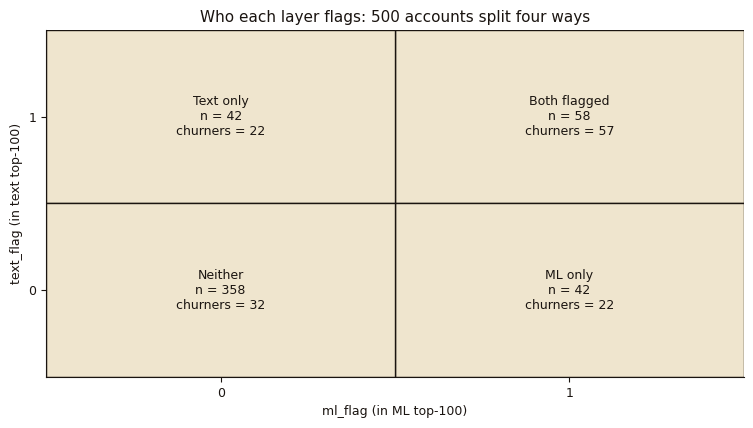

In [22]:
two_by_two = fusion_results["two_by_two"]
quadrants = [
    (1, 1, "both", "Both flagged"),
    (1, 0, "ml_only", "ML only"),
    (0, 1, "text_only", "Text only"),
    (0, 0, "neither", "Neither"),
]

fig, ax = plt.subplots(figsize=(9, 4.5))
for x, y, key, label in quadrants:
    data = two_by_two[key]
    rect = mpatches.Rectangle((x, y), 1, 1, facecolor=BEIGE, edgecolor=INK, linewidth=1)
    ax.add_patch(rect)
    cell_text = f"{label}\nn = {data['total_accounts']}\nchurners = {data['true_churners']}"
    ax.text(x + 0.5, y + 0.5, cell_text, ha="center", va="center", fontsize=9, color=INK)

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["0", "1"])
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["0", "1"])
ax.set_xlabel("ml_flag (in ML top-100)")
ax.set_ylabel("text_flag (in text top-100)")
ax.set_title("Who each layer flags: 500 accounts split four ways", fontsize=11, color=INK)
style_axis(ax)
plt.show()

In [23]:
# Archetype composition of each quadrant, as a table rather than a second chart.
archetype_composition = pd.DataFrame({
    label: two_by_two[key]["archetype_breakdown"] for _, _, key, label in quadrants
}).reindex(ARCHETYPE_ORDER)
display(archetype_composition)

,Both flagged,ML only,Text only,Neither
A1,0,10,1,165
A2,0,5,0,41
A3,40,11,4,2
A4,17,6,18,5
A5,0,5,0,25
A6,0,0,0,52
A7,1,1,19,34
A8,0,4,0,34


Of 58 accounts both layers flag, 57 are true churners (40 A3, 17 A4, 1 A7)– 
very high precision when both agree. The "text only" quadrant (42 accounts,
22 churners) is dominated by A4 (18) and A7 (19)–the money segment the ML
layer misses, sitting alongside the false positives the agent introduces.
The "ML only" quadrant is more archetype-mixed, including A5's honest misses
that the text layer correctly does not flag either.

### 5.4 The A4 table–the money segment

Of 46 A4 accounts:

,Approach,N of 46 A4 accounts
0,ML top-100,23
1,Text top-100,35
2,Combined top-100,37


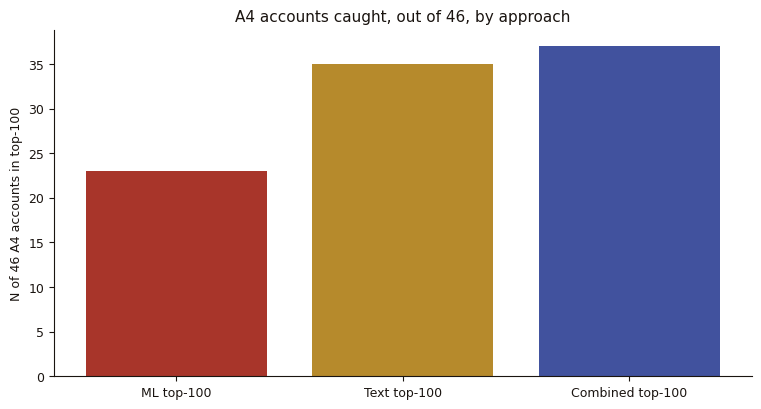

Headline delta: text vs ML = +12 accounts. Combined vs ML = +14 accounts.


In [24]:
a4_table_data = fusion_results["a4_table"]
a4_summary = pd.DataFrame({
    "Approach": ["ML top-100", "Text top-100", "Combined top-100"],
    "N of 46 A4 accounts": [a4_table_data["n_in_ml_top100"], a4_table_data["n_in_text_top100"], a4_table_data["n_in_combined_top100"]],
})
display(a4_summary)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(a4_summary["Approach"], a4_summary["N of 46 A4 accounts"], color=[WINE, GOLD, INDIGO])
ax.set_title("A4 accounts caught, out of 46, by approach", fontsize=11, color=INK)
ax.set_ylabel("N of 46 A4 accounts in top-100")
style_axis(ax)
plt.show()

print(f"Headline delta: text vs ML = +{a4_table_data['headline_delta_text_minus_ml']} accounts. "
      f"Combined vs ML = +{a4_table_data['headline_delta_combined_minus_ml']} accounts.")

Text alone surfaces 12 more A4 accounts than ML alone; combining the two
layers surfaces 14 more. This is the commercial core of the case study: the
segment that is hardest for a metadata-only model is exactly the segment the
text layer is built to catch.

### 5.5 The A7 rescue

The credibility check for fusion: does combining layers fix the agent's
false-positive rate on loud-but-loyal accounts, or does it just average it
into the noise.

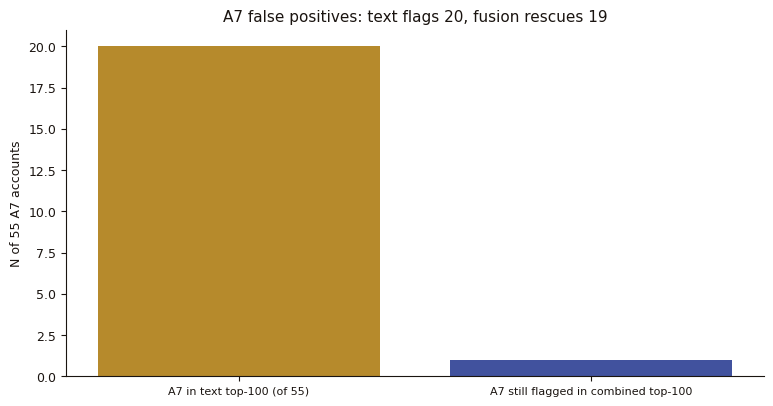

20 of 55 A7 accounts (36.4%) land in the text top-100.
Fusion rescues 19 of those 20; 1 remains flagged in the combined top-100.


In [25]:
a7_verdict = fusion_results["a7_verdict"]
a7_bars = pd.DataFrame({
    "Stage": [f"A7 in text top-100 (of {a7_verdict['n_a7_total']})", "A7 still flagged in combined top-100"],
    "N accounts": [a7_verdict["n_a7_in_text_top100"], a7_verdict["n_still_flagged_in_combined_top100"]],
})
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(a7_bars["Stage"], a7_bars["N accounts"], color=[GOLD, INDIGO])
ax.set_title("A7 false positives: text flags 20, fusion rescues 19", fontsize=11, color=INK)
ax.set_ylabel("N of 55 A7 accounts")
ax.tick_params(axis="x", labelsize=8)
style_axis(ax)
plt.show()

print(f"{a7_verdict['n_a7_in_text_top100']} of {a7_verdict['n_a7_total']} A7 accounts "
      f"({100*a7_verdict['pct_a7_polluting_text_top100']:.1f}%) land in the text top-100.")
print(f"Fusion rescues {a7_verdict['n_rescued_out_of_combined_top100']} of those 20; "
      f"{a7_verdict['n_still_flagged_in_combined_top100']} remains flagged in the combined top-100.")

The agent's raw text score alone would occasionally over-flag loud-but-loyal
accounts on tone. Fusion, dominated by `ml_risk_score` (which correctly reads
A7 as healthy–section 3.4), corrects all but one of those 20 false
positives. This is the argument for combining layers rather than trusting
either alone.

### 5.6 ARR business translation

Total ARR of all churned accounts: EUR 6,529,635.

,Approach,ARR caught at top-100 (EUR)
0,ML-only,3711649
1,Text-only,4349027
2,Combined,4571080


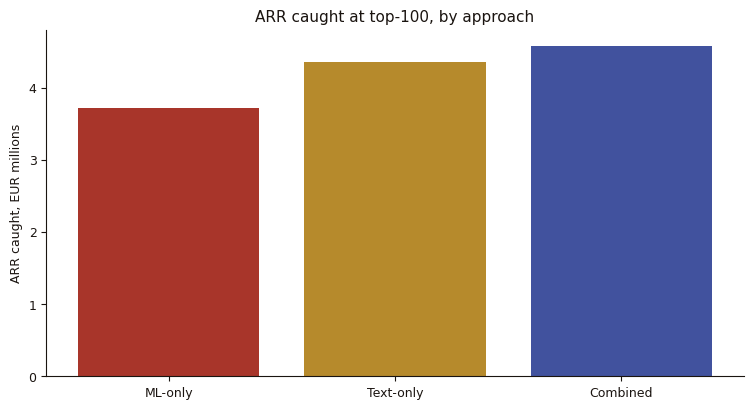

Incremental ARR text uniquely surfaces vs ML: EUR 1,340,728
Incremental ARR ML uniquely surfaces vs text: EUR 703,350


In [26]:
arr_data = fusion_results["arr_business_translation"]
arr_caught = arr_data["arr_caught_top100"]
arr_summary = pd.DataFrame({
    "Approach": ["ML-only", "Text-only", "Combined"],
    "ARR caught at top-100 (EUR)": [arr_caught["ml_only"], arr_caught["text_only"], arr_caught["combined"]],
})
display(arr_summary)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(arr_summary["Approach"], arr_summary["ARR caught at top-100 (EUR)"] / 1e6, color=[WINE, GOLD, INDIGO])
ax.set_title("ARR caught at top-100, by approach", fontsize=11, color=INK)
ax.set_ylabel("ARR caught, EUR millions")
style_axis(ax)
plt.show()

print(f"Incremental ARR text uniquely surfaces vs ML: EUR {arr_data['incremental_arr_text_uniquely_surfaces']:,}")
print(f"Incremental ARR ML uniquely surfaces vs text: EUR {arr_data['incremental_arr_ml_uniquely_surfaces']:,}")

Text-only catches more churned ARR than ML-only at the top-100 mark (EUR
4.35M vs 3.71M), and combined catches the most (EUR 4.57M). The EUR 1.34M
that text uniquely surfaces beyond ML is concentrated in exactly the A4
accounts section 5.4 identifies.

In [27]:
segmentation = fusion_results["segmentation"]
segmentation_table = pd.DataFrame({
    "Segment": ["Worth-saving", "Low-leverage"],
    "N accounts": [segmentation["worth_saving"]["n_accounts"], segmentation["low_leverage"]["n_accounts"]],
    "Total ARR (EUR)": [segmentation["worth_saving"]["total_arr"], segmentation["low_leverage"]["total_arr"]],
})
display(segmentation_table)
print(f"Segmentation rule: {segmentation['rule']}")

,Segment,N accounts,Total ARR (EUR)
0,Worth-saving,46,3831253
1,Low-leverage,54,1296425


Segmentation rule: worth-saving = arr_eur above the combined top-100 median (EUR 37,026) AND (frustration_trajectory == 'deteriorating' OR n_serious_competitor_mentions > 0); everything else in the combined top-100 is low-leverage.


Within the combined top-100, worth-saving accounts (above-median ARR and
either a deteriorating trajectory or a serious competitor mention) hold three
times the total ARR of the low-leverage remainder (EUR 3.83M vs 1.30M) in
under half the headcount–a retention team's review budget goes a lot
further if it is spent on the worth-saving segment first.

## 6. Honest limitations

**A5 (sudden death) is missed by both layers, by design.** Of 30 A5
accounts: 5 land in the ML top-100, 0 in the text top-100, 2 in the combined
top-100. A5's churn driver is exogenous–an acquisition, a budget cut, a
champion leaving–and genuinely leaves no trace in usage telemetry or
support text. Low, near-baseline counts here are the expected, honest
result, not a failure of either layer.

**A4 is half-visible to the classical model, not fully invisible.** Section
3.5 walked through why: three iterations of closing specific metadata leaks
(csat, then unresolved-ticket outcome) left a residual signal in ticket
*volume* that the model still partly reads, landing A4 at a 50.0% top-100
share versus A3's 89.5%. Closing that residual further would mean reducing
A4's ticket volume toward a healthy archetype's, which would also remove the
text signal the whole case study exists to demonstrate–a genuine design
tension, reported here rather than hidden.

**This is synthetic data with a known answer key.** It is built to prove a
mechanism–that an LLM agent reading support-ticket text can catch churn
signal that a metadata-only classical model cannot see, and that combining
the two beats either alone–rather than to claim that real-world churn
rates, archetype proportions, or the specific effect sizes above would
transfer directly to a live Kataja Analytics or any other company's data.